# 1. Introduction
-   **Weights & Biases Link:** [TODO: Link to my W&B report](https://wandb.ai/janis-kneubuehler-hochschule-luzern/janis-kneubuehler-nlp-project1/reports/I-BA_NLP-F2601-PIQA-Project-One--VmlldzoxNjM4MzI0MQ?accessToken=v75fk8fg8uj10657kmkivjcfcgrco9imi4h12vbhq6nm4unch0l2am3y92v9p05h)
-   **Tools & Sources Used:**
    - AI Tools
        - NotebookLM: Summarizing course materials and project description, Creating Template of Python Notebook with titles and descriptions
        - Gemini: Coding support / Learning help
        - Claude: Coding support
    - Others
        - Deepl: Translation 
        - PyTorch documentation
        - Course documents
        - Medium articles (important ones are in the specific markdown cells)


# 2. Setup & Data Loading
I used libraries that were covered in the course. I didn't evaluate different libraries.<br>I chose the ones with the biggest community in web.
Seed: I've also added the seed to the random library, because i wasn't sure if it is used by any other libraries as a sublibrary. Just to be on the safe side.

In [ ]:
# !pip install datasets gensim wandb nltk torch transformers

In [10]:
from transformers import AutoTokenizer

import torch
from datasets import load_dataset
import wandb
import numpy as np
import random

In [8]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [9]:
# Load the PIQA dataset from revision because dataset scripts are no longer supported
# Use splits like specified in Course Project Slides
train = load_dataset('ybisk/piqa', split='train[:-1000]', revision='refs/convert/parquet')
valid = load_dataset('ybisk/piqa', split='train[-1000:]', revision='refs/convert/parquet')
test = load_dataset('ybisk/piqa', split='validation', revision='refs/convert/parquet')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (552 > 512). Running this sequence through the model will result in indexing errors


99% of the dataset has fewer than 124 tokens.


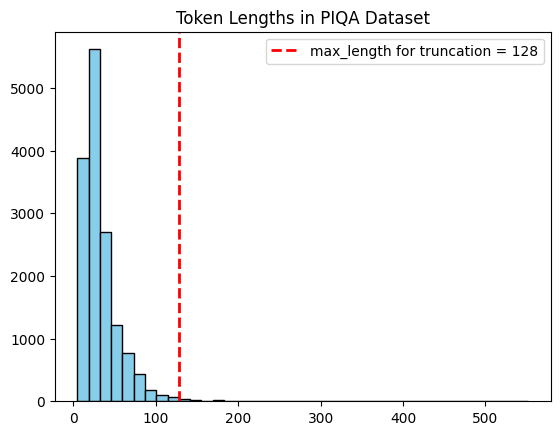

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer

# 1. Load data and tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# 2. Calculate token lengths for the text pairs
lengths = [len(tokenizer(ex["goal"] + " " + ex["sol1"])["input_ids"]) for ex in train]

# 3. Print the 99th percentile and plot it
print(f"99% of the dataset has fewer than {np.percentile(lengths, 99):.0f} tokens.")

plt.hist(lengths, bins=40, color='skyblue', edgecolor='black')
plt.axvline(128, color='red', linestyle='dashed', linewidth=2, label='max_length for truncation = 128')
plt.title('Token Lengths in PIQA Dataset')
plt.legend()
plt.show()

# 3. Preprocessing
**Decisions:**
- Truncation with Max Lenght 128:
Transformers handle memory differently: Unlike the LSTM used in Project 1, Transformers process all words at once. Memory usage grows quadratically based on the sequence length.

The data is short: As shown in the histogram above, 99% of the PIQA sentences are shorter than 124 tokens.

The decision: Setting max_length=128 acts as a safe upper limit. It ensures we do not cut off any actual words from our dataset, but strictly protects the GPU from crashing due to out-of-memory errors on rare, abnormally long sentences.

In [11]:
# 1. Load the DistilBERT tokenizer
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# 2. Define the preprocessing function
def preprocess_function(examples):
    # Duplicate the goal for each solution
    # Example: [[goal_0, goal_0], [goal_1, goal_1]]
    first_sentences = [[context] * 2 for context in examples["goal"]]
    
    # Pair them with the corresponding solutions
    # Example: [[sol1_0, sol2_0], [sol1_1, sol2_1]]
    second_sentences = [
        [sol1, sol2] for sol1, sol2 in zip(examples["sol1"], examples["sol2"])
    ]

    # Flatten the lists to 1D so the tokenizer can process them efficiently
    first_sentences = sum(first_sentences, [])
    second_sentences = sum(second_sentences, [])

    # Tokenize the pairs
    # Note: DistilBERT does NOT return token_type_ids, which is expected!
    tokenized_examples = tokenizer(
        first_sentences,
        second_sentences,
        truncation=True,
        max_length=128, # 128 is plenty for the PIQA dataset
        padding="max_length"
    )

    # Un-flatten the tokenized features back into pairs of 2
    # This transforms the flat list back into the (batch_size, 2, sequence_length) shape
    features = {
        k: [v[i : i + 2] for i in range(0, len(v), 2)]
        for k, v in tokenized_examples.items()
    }
    
    return features

# 3. Apply the function to all dataset splits
# We use batched=True so the flattening/unflattening logic works
encoded_train = train.map(preprocess_function, batched=True)
encoded_valid = valid.map(preprocess_function, batched=True)
encoded_test = test.map(preprocess_function, batched=True)

# 4. Format the datasets for PyTorch
# We remove the original string columns because PyTorch DataLoaders only want tensors
columns_to_return = ['input_ids', 'attention_mask', 'label']

encoded_train.set_format(type='torch', columns=columns_to_return)
encoded_valid.set_format(type='torch', columns=columns_to_return)
encoded_test.set_format(type='torch', columns=columns_to_return)

# Let's check the shape to make sure it worked!
print(f"Shape of input_ids for one example: {encoded_train[0]['input_ids'].shape}")
# Expected output: torch.Size([2, 128])

Map: 100%|██████████| 1838/1838 [00:00<00:00, 9947.98 examples/s]


Shape of input_ids for one example: torch.Size([2, 128])


# 4. Model Definition
**Decisions:**
For my Transformer models, I chose distilbert-base-uncased. Standard BERT has an advantage here because its token_type_ids help the model tell the difference between the two parts of goal and the solution. Even though DistilBERT misses this feature and only uses the [SEP] token, I chose it because the faster training time and lower memory usage are more important for my setup.

distilbert-base-uncased

# 5. Training
**Decissions / Clarification:**
- **Loss Function:** I use CrossEntropyLoss and not BCELoss. It is easier to understand for me and does not need a Sigmoid function. It should not make a difference in quality.
- **Optimizer & Regularization:** I use the Adam optimizer, which is a standard choice for these architectures and was suggested in the project discussion. I added a Weight Decay to the optimizer in Architecture 2, because it was overfitting. This was suggested by Gemini. In hindsight, I'd try the AdamW optimization for the architecture 2 as it is very high-dimensial with the unfrozen word2vec embeddings. (https://yassin01.medium.com/adam-vs-adamw-understanding-weight-decay-and-its-impact-on-model-performance-b7414f0af8a1)
- **Experiment Design:** My primary goal was to find a configuration that stops Architecture 2 from overfitting. To find this out, I kept the batch size locked at 64 and experimented with decreasing the learning rate (down to 1e-5) and after fixing lr increasing Dropout (up to 0.5) to force the model to generalize.
- **Number of training runs:** I ran approximately 10-15 manual training runs per model. I tracked all of them in Weights & Biases to compare the validation loss curves and identify the optimal hyperparameter combination for the final model.
- **Early Stopping & Checkpointing:** I implemented Early Stopping based on Validation Accuracy with a patience of 6 to 10 epochs. I save the last model if my rund would get aborted and the best model.
- **Validation:** I use torch.no_grad() during the validation and testing loops to disable gradient tracking. This was something Claude discovered that i missed. It guarantees the model doesn't learn from the validation set and saves memory.

In [ ]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, checkpoint_name, epochs=20, patience=3):
    best_val_accuracy = 0.0
    patience_counter = 0
    checkpoint_best_path = f"best_{checkpoint_name}_model.pt"
    checkpoint_last_path = f"last_{checkpoint_name}_model.pt" # Save last model if my run gets aborted
    print(f"Number of batches {len(train_loader)}")

    for epoch in range(epochs):
        ########################## Training ##########################
        model.train()
        total_train_loss = 0.0
        
        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(batch['input1'], batch['input2'])
            loss   = criterion(logits, batch['labels'])
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            
        avg_train_loss = total_train_loss / len(train_loader)
        
        ########################## Validation ##########################
        model.eval()
        total_val_loss = 0.0
        correct_preds = 0
        total_preds = 0
        
        with torch.no_grad():
            for batch in valid_loader:
                logits = model(batch['input1'], batch['input2'])
                loss   = criterion(logits, batch['labels'])
                total_val_loss += loss.item()
                
                predictions = torch.argmax(logits, dim=1)
                correct_preds += (predictions == batch['labels']).sum().item()
                total_preds += batch['labels'].size(0)
                
        avg_val_loss = total_val_loss / len(valid_loader)
        val_accuracy = correct_preds / total_preds
        
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": val_accuracy
        })
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")
        
        ########################## Checkpoints ##########################
        torch.save(model.state_dict(), checkpoint_last_path)
        
        if val_accuracy > best_val_accuracy: # Best model & early stopping based on validation accuracy (as discussed in project discussion)
            print(f"Validation accuracy improved from {best_val_accuracy:.4f} to {val_accuracy:.4f}. Saving checkpoint.")
            best_val_accuracy = val_accuracy
            patience_counter = 0
            
            torch.save(model.state_dict(), checkpoint_best_path)
        else:
            patience_counter += 1
            print(f"No improvement in validation accuracy. Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs!")
                break # Exit the training loop

    print(f"Training complete. Saved best and last model.")

In [ ]:
import torch.optim as optim

# Login to W&B
wandb.login()

wandb.init(
    project="janis-kneubuehler-nlp-project1", 
    config={
        "architecture": "ArchitectureOne",
        "run_goal": "decrease dropout",
        "learning_rate": 1e-3,
        "hidden_dim": 128,
        "dropout": 0.2,
        "epochs": 30,
        "batch_size": batch_size
    }
)
config = wandb.config

model = ArchitectureOne(embedding_matrix, hidden_dim=128, dropout_rate=config.dropout)

criterion = nn.CrossEntropyLoss()

trainable_parameters = (p for p in model.parameters() if p.requires_grad)
optimizer = optim.Adam(trainable_parameters, lr=config.learning_rate)

train_model(model, train_loader, valid_loader, criterion, optimizer, checkpoint_name=f"arch1", epochs=config.epochs, patience=6)

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/janis.kneubuehler/.netrc.
wandb: Currently logged in as: janis-kneubuehler (janis-kneubuehler-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Number of batches 237
Epoch 1/30 | Train Loss: 0.6926 | Val Loss: 0.6918 | Val Acc: 0.5450
Validation accuracy improved from 0.0000 to 0.5450. Saving checkpoint.
Epoch 2/30 | Train Loss: 0.6901 | Val Loss: 0.6897 | Val Acc: 0.5500
Validation accuracy improved from 0.5450 to 0.5500. Saving checkpoint.
Epoch 3/30 | Train Loss: 0.6871 | Val Loss: 0.6880 | Val Acc: 0.5660
Validation accuracy improved from 0.5500 to 0.5660. Saving checkpoint.
Epoch 4/30 | Train Loss: 0.6847 | Val Loss: 0.6869 | Val Acc: 0.5580
No improvement in validation accuracy. Patience: 1/6
Epoch 5/30 | Train Loss: 0.6824 | Val Loss: 0.6861 | Val Acc: 0.5580
No improvement in validation accuracy. Patience: 2/6
Epoch 6/30 | Train Loss: 0.6791 | Val Loss: 0.6860 | Val Acc: 0.5530
No improvement in validation accuracy. Patience: 3/6
Epoch 7/30 | Train Loss: 0.6781 | Val Loss: 0.6854 | Val Acc: 0.5640
No improvement in validation accuracy. Patience: 4/6
Epoch 8/30 | Train Loss: 0.6743 | Val Loss: 0.6847 | Val Acc: 0.5590
N

epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
train_loss,██▇▇▆▆▆▅▄▄▄▃▃▂▂▁▁
val_accuracy,▁▂▆▄▄▃▆▅▆▆█▄▆▆▆▇▇
val_loss,█▆▅▄▄▄▃▃▂▂▁▂▁▁▁▁▁
epoch,17
train_loss,0.65118
val_accuracy,0.569
val_loss,0.68276


In [ ]:
import torch.optim as optim

# Login to W&B
wandb.login()

wandb.init(
    project="janis-kneubuehler-nlp-project1", 
    config={
        "architecture": "ArchitectureTwo",
        "run_goal": "decrease learning_rate due to model starvation",
        "learning_rate": 1e-4,
        'lstm_hidden_dim': 128,
        'classifier_hidden_dim': 128,
        'num_layers': 2,
        "dropout": 0.5,
        "epochs": 30,
        "batch_size": batch_size
    }
)
config2 = wandb.config

model2 = ArchitectureTwo(embedding_matrix, lstm_hidden_dim=config2.lstm_hidden_dim, classifier_hidden_dim=config2.classifier_hidden_dim, num_layers=config2.num_layers, dropout_rate=config2.dropout)
criterion2  = nn.CrossEntropyLoss()
optimizer2  = optim.Adam(model2.parameters(), lr=config2.learning_rate, weight_decay=1e-4)

train_model(model2, train_loader, valid_loader, criterion2, optimizer2, checkpoint_name=f"arch2", epochs=config2.epochs, patience=10)

wandb.finish()

Number of batches 237
Epoch 1/30 | Train Loss: 0.6932 | Val Loss: 0.6931 | Val Acc: 0.5580
Validation accuracy improved from 0.0000 to 0.5580. Saving checkpoint.
Epoch 2/30 | Train Loss: 0.6929 | Val Loss: 0.6928 | Val Acc: 0.5690
Validation accuracy improved from 0.5580 to 0.5690. Saving checkpoint.
Epoch 3/30 | Train Loss: 0.5059 | Val Loss: 0.8388 | Val Acc: 0.5640
No improvement in validation accuracy. Patience: 1/10
Epoch 4/30 | Train Loss: 0.3809 | Val Loss: 0.9914 | Val Acc: 0.5650
No improvement in validation accuracy. Patience: 2/10
Epoch 5/30 | Train Loss: 0.3236 | Val Loss: 1.0782 | Val Acc: 0.5540
No improvement in validation accuracy. Patience: 3/10
Epoch 6/30 | Train Loss: 0.2724 | Val Loss: 1.2273 | Val Acc: 0.5510
No improvement in validation accuracy. Patience: 4/10
Epoch 7/30 | Train Loss: 0.2401 | Val Loss: 1.1573 | Val Acc: 0.5470
No improvement in validation accuracy. Patience: 5/10
Epoch 8/30 | Train Loss: 0.2140 | Val Loss: 1.3153 | Val Acc: 0.5500
No improvement

epoch,▁▂▂▃▄▄▅▅▆▇▇█
train_loss,██▆▄▃▃▂▂▂▁▁▁
val_accuracy,▅█▆▇▃▂▁▂▂▄▄▅
val_loss,▁▁▂▃▄▅▄▅▆▆▇█
epoch,12
train_loss,0.15089
val_accuracy,0.558
val_loss,1.68876


# 6. Evaluation
The models evaluated werde renamed manually by myself.
For the evaluation I used the models with the following reasons:
- Architecture 1: "fearless-silence-19" selected for its low validation loss (0.683) after decreasing dropout to 0.2. It safely avoided the overfitting seen in runs with artificially higher peak accuracies.
- Architecture 2: "trim-star-21" selected because it achieved the highest validation accuracy (57.7%) among all Architecture 2 experiments after successfully increasing the batch size to 64.

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss    = 0.0
    correct_preds = 0
    total_preds   = 0

    with torch.no_grad():
        for batch in loader:
            logits = model(batch['input1'], batch['input2'])
            loss   = criterion(logits, batch['labels'])
            total_loss    += loss.item()
            predictions    = torch.argmax(logits, dim=1)
            correct_preds += (predictions == batch['labels']).sum().item()
            total_preds   += batch['labels'].size(0)

    return total_loss / len(loader), correct_preds / total_preds

########################## Architecture 1 ##########################
model.load_state_dict(torch.load("./best_arch1_model.pt")) # My best Model of Arch1

val_loss1,  val_acc1  = evaluate(model, valid_loader, criterion)
test_loss1, test_acc1 = evaluate(model, test_loader,  criterion)
print(f"Architecture 1 – Validation, Loss: {val_loss1:.4f}, Accuracy: {val_acc1:.4f}")
print(f"Architecture 1 – Test, Loss: {test_loss1:.4f}, Accuracy: {test_acc1:.4f}")

########################## Architecture 2 ##########################
model2.load_state_dict(torch.load("./best_arch2_model.pt")) # My best Model of Arch2

val_loss2,  val_acc2  = evaluate(model2, valid_loader, criterion2)
test_loss2, test_acc2 = evaluate(model2, test_loader,  criterion2)
print(f"Architecture 2 – Validation, Loss: {val_loss2:.4f}, Accuracy: {val_acc2:.4f}")
print(f"Architecture 2 – Test, Loss: {test_loss2:.4f}, Accuracy: {test_acc2:.4f}")

Architecture 1 – Validation, Loss: 0.6821, Accuracy: 0.5750
Architecture 1 – Test, Loss: 0.6848, Accuracy: 0.5620
Architecture 2 – Validation, Loss: 0.7025, Accuracy: 0.5780
Architecture 2 – Test, Loss: 0.6924, Accuracy: 0.5773


# 7. Conclusion & Interpretation
**Results Summary:**
Both architectures achieved very similar results on the unseen test set, hovering around 56-57% accuracy. Since there are only two possible answers per question, random guessing would be 50%. While both models learned something, they clearly struggled with the task. The results are not much better than a coin flip.

**Model Comparison:**
Architecture 1: This model was incredibly fast to train. Because the embeddings were frozen, it was highly resistant to overfitting. However, because Mean Pooling blends all words into a single average vector, it loses the word order. Since the model completely ignores the grammatical order of the words, it knows which objects are in the sentence, but has no idea how they interact with each other.

Architecture 2: In my expections this model should be much smarter because the bidirectional LSTM reads the sequence and preserves grammar. However, because I unfroze the embeddings, the model had millions of trainable parameters. The training process was much longer and I had the problem of overfitting. Even with different strategies like high dropout and Weight Decay, it failed to generalize better than the simpler baseline.

**Interpretation:**
The PIQA dataset tests physical commonsense. Word2Vec embeddings only know which words appear next to each other in Web articles. They don't actually understand physical properties. These final results clearly demonstrate that it is extremely difficult for basic text-only models to learn real-world physics purely from the statistical distribution of words.